<a href="https://colab.research.google.com/github/Taniacrz93/telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:

# mostrar las primeras 5 filas de users
users.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:

# cantidad de nulos para users
print("Cantidad de valores nulos users:")
print(users.isna().sum())
print("Proporción de valores nulos users")
print(users.isna().mean())


Cantidad de valores nulos users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos users
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print("Cantidad de valores nulos usage:")
print(usage.isna().sum())
print("Proporción de valores nulos usage")
print(usage.isna().mean())

Cantidad de valores nulos usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos usage
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Columnas del dataset users con valores nulos**
- City (11.7%): contiene una proporción moderada de valores nulos. Se recomienda investigar si es posible recuperar esta información a partir de otras fuentes; de no ser posible, conservar los valores nulos, ya que no es adecuado imputar una ciudad sin evidencia
- Churn_date (88.3%): Aún cuando presenta una alta proporción de valores nulos, estos parecen tener un significado dentro del negocio, ya que indicarían que la línea continúa activa. Por ello se recomienda conservar la columna y no imputar ni eliminar estos valores

**Columnas del dataset usage con valores nulos**
- Date (0.12%): presenta una proporción muy baja de valores nulos. Se recomienda investigar estos casos y, dependiendo del análisis, conservarlos como nulos o excluir únicamente esos registros si la fecha es indispensable.
- Duration (55.19%): la elevada proporción de valores nulos sugiere que podrían no corresponder a un error de calidad de datos. Se recomienda investigar si los nulos están relacionados con el tipo de registro antes de decidir si deben imputarse o mantenerse.
- Length (44.7%): al igual que en el caso anterior, se recomienda analizar si los valores nulos dependen del tipo de uso registrado y determinar si representan un comportamiento esperado en lugar de un dato faltante.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:

# explorar columnas numéricas de users
users[["user_id","age"]].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` presenta valores dentro del rango de 10000 y 13999, sin evidencia de valores inválidos o sentinels. Al tratarse de un identificador único, no se observan anomalías en su rango
- La columna `age` presenta un valor mínimo de -999, el cual no es una edad válida y probablemente corresponde a un sentinel. Este valor atípico afecta las estadísticas descriptivas, especialmente la media y la desviación estándar, por lo que deberá tratarse durante la etapa de limpieza de datos

In [ ]:
# explorar columnas numéricas de usage
usage[["id","user_id","duration","length"]].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` no presentan evidencia de valores inválidos o sentinels. Al tratarse de identificadores sus rangos son consistentes y no se observan anomalías.
- Las columnas 'duration' y 'length' no presentan valores negativos ni sentinels evidentes. Sin embargo, ambas contienen registros con valor 0, por lo que será necesario verificar si estos representan valores válidos dentro del contexto de negocio o si corresponden a datos faltantes o registros especiales.

In [ ]:

# explorar columnas categóricas de users

columnas_user = ['city', 'plan']
for col in columnas_user:
    print(col, ":")
    print(users[col].value_counts(dropna=False))
    print()




city :
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan :
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` contiene registros de 6 ciudades. Sin embargo, presenta 469 valores nulos y 96 registros con el valor "?", el cual podría representar un sentinel. Será necesario verificar si estos registros se pueden imputar o, en su caso, tratar el valor "?" como un dato faltante.
- La columna `plan` contiene únicamente dos categorías, básico y premium, sin valores nulos ni categorías inesperadas, por lo que no se observan indicios de valores inválidos o sentinels.

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` contiene únicamente dos categorías (text y call), sin valores nulos ni categorías adicionales que sugieran errores de captura o sentinels

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Las columnas en las que recomiendo acciones son en las siguientes:
- Age: el valor -999 se identificó como un sentinel, ya que no representa una edad válida. Se recomienda reemplazarlo por un valor nulo (NaN) para evitar que afecte las estadísticas descriptivas y permitir un tratamiento adecuado durante la limpieza de datos.
- Duration y Length: Estas columnas presentan un alto porcentaje de valores nulos. Sin embargo, estos parecen estar asociados al tipo de registro (call o text), en consecuencia, los valores nulos se conservarán, ya que representan información no aplicable para cierto tipo de evento.
- City: Se identificaron 96 registros con el valor "?". Se recomienda reemplazar este valor por NaN para unificar el tratamiento de los datos faltantes.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False)

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observan registros correspondientes a los años 2022, 2023 y 2024, con una cantidad similar de usuarios en cada uno. Sin embargo, también se identifican 40 registros del año 2026, los cuales se encuentran fuera del rango temporal esperado. Se recomienda revisar estos registros para determinar si corresponden a un error de captura y definir el tratamiento adecuado.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False)

2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, se observa que la mayoría de los registros corresponden al año 2024. Además se identifican 50 valores nulos. Se recomienda revisarlos y definir el tratamiento adecuado antes de realizar el análisis temporal  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Diagnóstico**
En la columna 'reg_date' de users aparecen 40 registros correspondientes al año 2026, valores que se encuentran fuera del rango esperado. En 'date' de usage no se observan datos fuera de rango pero sí 50 valores nulos.

**Acción recomendada**
Revisar los registros con fechas fuera de rango para confirmar si se trata de errores de captura. Si no es posible recuperar la fecha correcta, se recomienda tratarlos como valores faltantes o eliminarlos del análisis, según su impacto. En el caso de los valores nulos en usage['date'], se recomienda revisar y excluir del análisis temporal si no es posible recuperar la información.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:



# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()




count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city']=users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:

# Marcar fechas futuras como NA para reg_date
users['reg_date']=users['reg_date'].where(users['reg_date'].dt.year<=2024,pd.NaT)

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)


2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:

# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:

# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()


type
call    0.99933
text    0.00000
Name: length, dtype: float64

Se verificó la distribución de valores nulos en `duration` y `length` agrupando por la variable 'type'. Se observó que aproximadamente el 99.9% de los registros del tipo text tienen duration nula y el 99.9% de los registros de tipo call tienen length nila. Esto indica que la ausencia de datos depende del tipo de evento y no de un error, por ello, se recomienda conservar estos valores nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:


# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    "is_text": "sum",
    "is_call":"sum",
    "duration":"sum"
}).reset_index()

# observar resultado

usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:


# Renombrar columnas
usage_agg=usage_agg.rename(columns={'is_text':'cant_mensajes',
                          'is_call':'cant_llamadas',
                          'duration':'cant_minutos_llamada'
                         })

# observar resultado
usage_agg.head(3)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg,
                          on='user_id',
                          how='left')
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

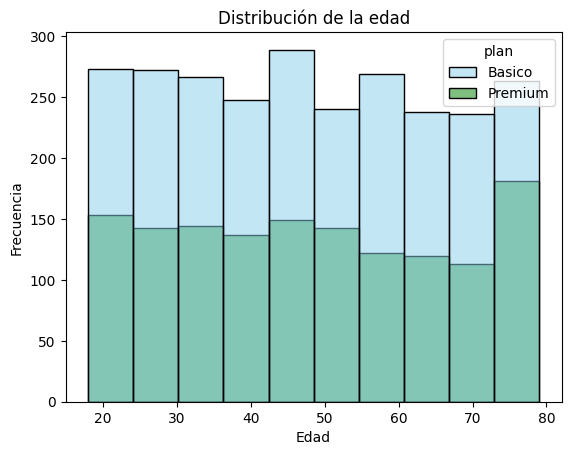

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,x='age',hue='plan',bins=10,palette=['skyblue','green'])
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Distribución de la edad")
plt.show()

💡Insights:
- La distribución de la edad es relativamente uniforme, ya que los usuarios se encuentran distribuidos en casi todos los rangos de edad sin una concentración clara.
- Se observa un ligero aumento alrededor de los 45 a 50 años, aunque no es lo suficientemente marcado para indicar un patrón predominante.
- La forma de la distrubución es similar entre los planes Básico y Premium.
- El plan Básico presenta una mayor frecuencia de usuarios en prácticamente todos los rangos de edad, lo cual es consistente con que cuenta con un mayor número de usuarios.

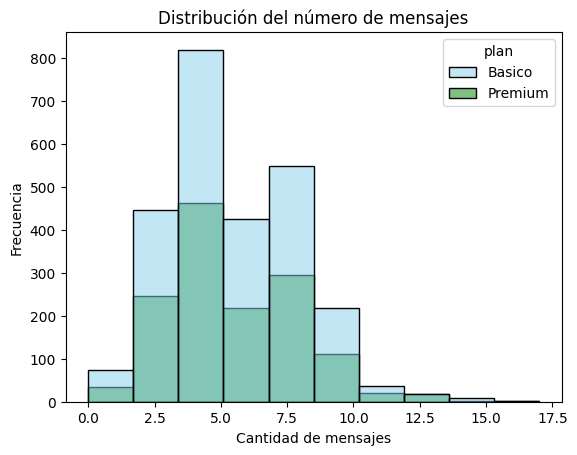

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,x='cant_mensajes',hue='plan',bins=10,palette=['skyblue','green'])
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.title("Distribución del número de mensajes")
plt.show()

💡Insights:
- La mayor concentración de usuarios envía entre 3 y 8 mensajes.
- La distribución presenta un sesgo hacia la derecha, ya que la frecuencia disminuye conforme aumenta el número de mensajes y existe una cola hacia los valores más altos.
- La forma de la distribución es similar para los planes Básico y Premium.
- El plan Básico presenta una mayor frecuencia de usuarios en la mayoría de los intervalos, lo cual es consistente con el mayor número de usuarios registrados en ese plan.

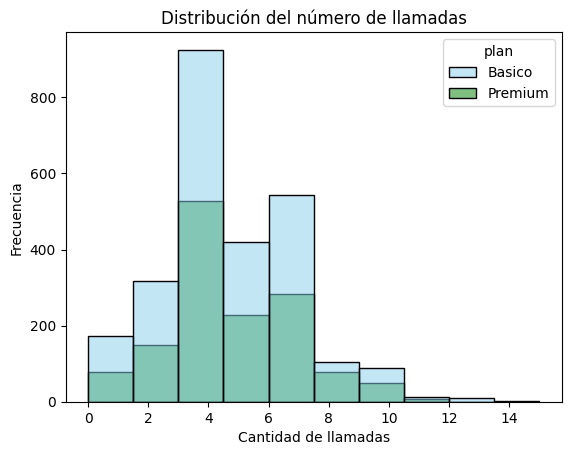

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile,x='cant_llamadas',hue='plan',bins=10,palette=['skyblue','green'])
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.title("Distribución del número de llamadas")
plt.show()

💡Insights:
- Se observa una mayor concentración de llamadas entre 3 y 5 llamadas.
- La distribución presenta un sesgo hacia la derecha, ya que existe una cola hacia los valores más altos.
- El plan Básico presenta una mayor frecuencia de usuarios en la mayoría de los intervalos, lo cual es consistente con el mayor número de usuarios registrados en ese plan.

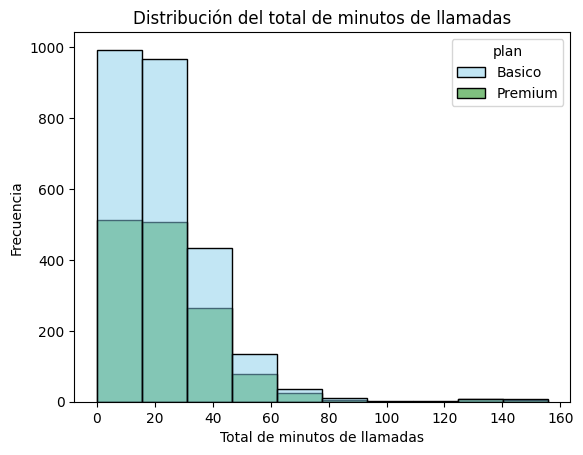

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,x='cant_minutos_llamada',hue='plan',bins=10,palette=['skyblue','green'])
plt.xlabel("Total de minutos de llamadas")
plt.ylabel("Frecuencia")
plt.title("Distribución del total de minutos de llamadas")
plt.show()

💡Insights:
- Se observa una mayor concentración de usuarios con entre 0 y 30 minutos de llamadas.
- La distribución presenta un sesgo hacia la derecha, ya que la frecuencia disminuye conforme aumentan los minutos de llamada y existe una cola hacia valores más altos.
- La forma de la distribución es similar para los planes Básico y Premium
- El plan Básico presenta una mayor frecuencia de usuarios en todos los intervalos de minutos, lo cual es consistente con que cuenta con un mayor número de usuarios registrados.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

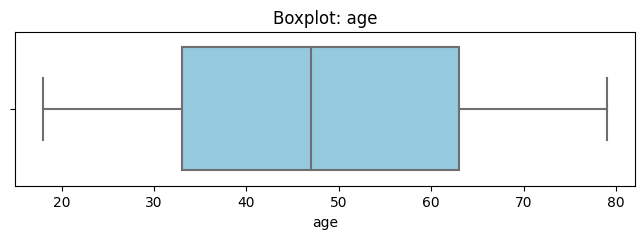

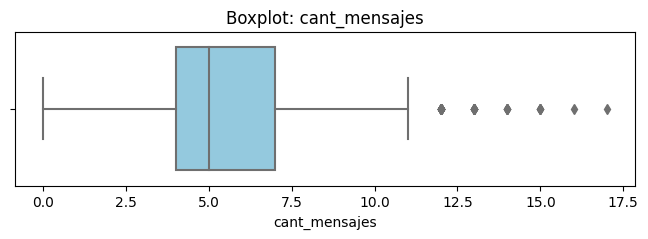

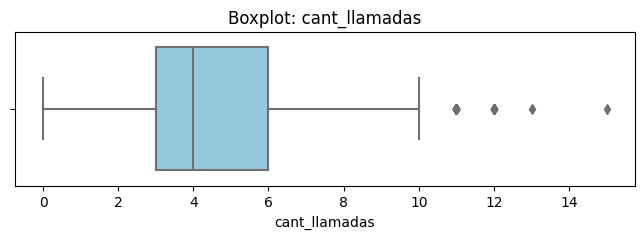

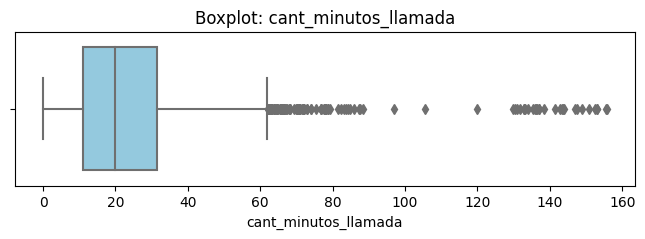

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=user_profile[col],color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- En la variable age no se observan valores atípicos (outliers), ya que no existen observaciones fuera de los bigotes del boxplot.
- En cant_mensajes se observan algunos outliers únicamente en el extremo superior, correspondientes a usuarios que envían una cantidad de mensajes mayor a la mayoría.
- La variable cant_llamadas también presenta algunos outliers en el límite superior, lo que indica que existen usuarios con un número de llamadas considerablemente mayor que el resto.
- En cant_minutos_llamada se observa una mayor cantidad de outliers en el extremo superior, lo que indica que algunos usuarios acumulan muchos más minutos de llamadas que la mayoría.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    q1=user_profile[col].quantile(0.25)
    q3=user_profile[col].quantile(0.75)
    iqr=q3-q1
    limite_superior=q3+1.5*iqr
    print(f'IQR de {col}: {iqr}')
    print(f'Límite superior de {col}: {limite_superior}')
    print()

IQR de cant_mensajes: 3.0
Límite superior de cant_mensajes: 11.5

IQR de cant_llamadas: 3.0
Límite superior de cant_llamadas: 10.5

IQR de cant_minutos_llamada: 20.295
Límite superior de cant_minutos_llamada: 61.8575



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:

- cant_mensajes: Mantener los outliers. Aunque existen valores por encima del límite superior (11.5), el máximo registrado (17) es un valor posible para usuarios con un uso intensivo del servicio. No hay evidencia de errores de captura, por lo que conservarlos permite representar adecuadamente el comportamiento real de los usuarios.
- cant_llamadas: Mantener los outliers. El valor máximo (15) supera el límite superior (10.5), pero sigue siendo un valor plausible dentro del contexto de uso de un servicio de telefonía. Estos registros representan usuarios con una mayor frecuencia de llamadas y aportan información relevante al análisis.
- cant_minutos_llamada: Mantener los outliers. Aunque el máximo (155.69) excede considerablemente el límite superior (61.8575), no se observan indicios de errores o valores imposibles. Es razonable que algunos usuarios acumulen muchos más minutos de llamada que el resto, por lo que eliminarlos podría sesgar el análisis del consumo real del servicio.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def segmentacion_uso(row):
    llamadas=row['cant_llamadas']
    mensajes=row['cant_mensajes']

    if pd.isna(llamadas) or pd.isna(mensajes):
        return "Error en Datos"

    if llamadas<5 and mensajes<5:
        return "Bajo uso"
    elif llamadas <10 and mensajes <10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile['grupo_uso']=user_profile.apply(segmentacion_uso,axis=1)
user_profile["grupo_uso"].value_counts()

Uso medio         2943
Bajo uso           778
Alto uso           278
Error en Datos       1
Name: grupo_uso, dtype: int64

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def segmentacion_edad(row):
    edad=row['age']

    if pd.isna(edad):
        return "Error en Datos"

    if edad<30:
        return "Joven"
    elif edad<60:
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile['grupo_edad']=user_profile.apply(segmentacion_edad,axis=1)
user_profile["grupo_edad"].value_counts()


Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

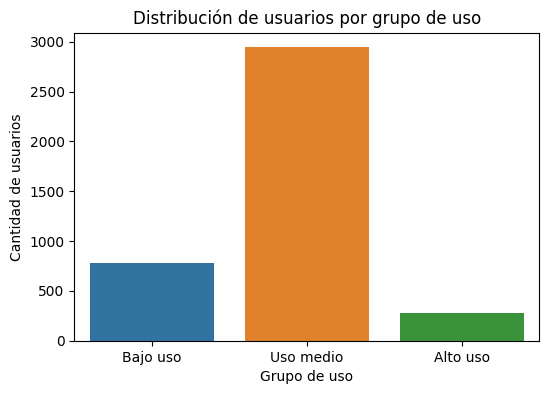

In [ ]:
# Visualización de los segmentos por uso
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile[user_profile['grupo_uso']!='Error en Datos']
              ,x='grupo_uso',
             order=['Bajo uso','Uso medio','Alto uso'])
plt.title("Distribución de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()

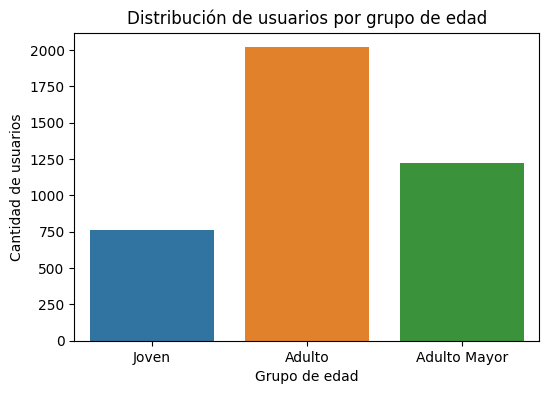

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile,x='grupo_edad',order=['Joven','Adulto','Adulto Mayor'])
plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron 469 valores faltantes en la columna city (11.7%), además de registros con el valor "?", los cuales se reemplazaron por valores nulos.
- La columna churn_date presentó 3,534 valores nulos (88.35%), los cuales corresponden a usuarios que permanecen activos, por lo que no representan un error.
- En la columna age se encontraron valores inválidos (-999), los cuales fueron sustituidos por la mediana para conservar los registros.
- En la tabla de uso se detectaron 50 fechas faltantes (0.125%) y valores nulos en duration (55.19%) y length (44.7%). Tras el análisis se determinó que estos valores dependen del tipo de evento (llamada o mensaje), por lo que se conservaron al no representar inconsistencias.

🔍 **Segmentos por Edad**
- El grupo de Adultos (30 a 59 años) representa el 50.5% de los usuarios, siendo el segmento más numeroso.
- Los Adultos Mayores constituyen el 30.6% de la población, mientras que los Jóvenes representan el 19.0%.


📊 **Segmentos por Nivel de Uso**
- El 73.6% de los usuarios pertenece al segmento de Uso medio, convirtiéndose en el grupo predominante.
- El 19.5% corresponde a Bajo uso, mientras que el 7.0% pertenece a Alto uso.
- Se identificaron valores atípicos en llamadas, mensajes y minutos consumidos; sin embargo, estos representan comportamientos reales de algunos usuarios y no errores en los datos, por lo que fueron conservados en el análisis.


➡️ Esto sugiere que la mayor parte de la cartera de clientes mantiene un nivel de consumo moderado y pertenece al grupo de adultos. Aunque el segmento de alto uso es reducido, representa una oportunidad para ofrecer planes con mayores beneficios dirigidos a usuarios intensivos. Por otro lado, los usuarios de bajo uso podrían beneficiarse de planes más económicos o flexibles que favorezcan su permanencia.

💡 **Recomendaciones**
- Mantener una oferta competitiva para el segmento de Uso medio, ya que concentra la mayoría de los clientes.
- Diseñar planes premium o con beneficios adicionales para usuarios de Alto uso, considerando su mayor consumo.
- Evaluar planes básicos o flexibles para usuarios de Bajo uso, con el objetivo de mejorar la retención.
- Continuar implementando procesos de validación de datos para evitar valores inválidos como edades negativas o ciudades registradas con caracteres no válidos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`